In [161]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression


df_final = pd.read_csv("../data/treated/df_final.csv")

In [162]:
df_final = df_final.drop("Unnamed: 0", axis=1)

In [ ]:
X = df_final.drop("heartdisease", axis=1)
y = df_final["heartdisease"]

## Data Split

In [277]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=16)

## Logistic Regression

### Model v1: using all columns

In [278]:
X.columns

Index(['Unnamed: 0', 'age', 'restingbp', 'cholesterol', 'maxhr', 'oldpeak',
       'hr_ratio', 'sex', 'fastingbs', 'exerciseangina', 'elderly',
       'max_hr_predicted', 'restingecg_normal', 'restingecg_st',
       'st_slope_flat', 'st_slope_up', 'oldpeak_risk_low',
       'oldpeak_risk_moderated', 'chestpaintype_ata', 'chestpaintype_nap',
       'chestpaintype_ta'],
      dtype='str')

In [279]:
clf_v1 = LogisticRegression(max_iter=1500)
clf_v1.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [282]:
y_pred_v1 = clf_v1.predict(X_test)

### v1 Metrics

In [297]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, ConfusionMatrixDisplay

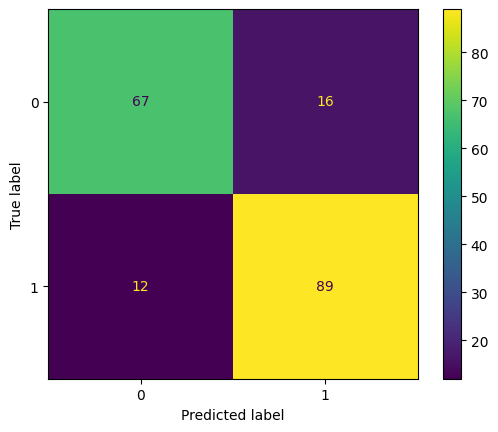

In [286]:
cm_v1 = confusion_matrix(y_test, y_pred_v1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_v1, display_labels=clf_v1.classes_)
disp.plot();

In [299]:
print(f"Accuracy score: {accuracy_score(y_test, y_pred_v1):.2f}")

Accuracy score: 0.85


In [288]:
print(f"Recall score: {recall_score(y_test, y_pred_v1, average='binary'):.2f}")
print("Ability to find all the positive samples.")

Recall score: 0.88
Ability to find all the positive samples.


In [290]:
print(f"Precision: {precision_score(y_test, y_pred_v1):.2f}")
print("Ability not to label as positive a sample that is negative.")

Precision: 0.85
Ability not to label as positive a sample that is negative.


### Model v2: Dropping "oldpeak"

In [303]:
X_train_v2 = X_train.drop("oldpeak", axis=1)
X_test_v2 = X_test.drop("oldpeak", axis=1)

In [304]:
clf_v2 = LogisticRegression(max_iter=1500)
clf_v2.fit(X_train_v2, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [305]:
y_pred_v2 = clf_v2.predict(X_test_v2)

#### Models v1 and v2 metrics comparison

In [310]:
print(f"Model v1 Accuracy Score: {accuracy_score(y_test, y_pred_v1):.2f}")
print(f"Model v2 Accuracy Score: {accuracy_score(y_test, y_pred_v2):.2f}")
print(f"Model v1 Recall Score: {recall_score(y_test, y_pred_v1):.2f}")
print(f"Model v2 Recall Score: {recall_score(y_test, y_pred_v2):.2f}")
print(f"Model v1 Precision Score: {precision_score(y_test, y_pred_v1):.2f}")
print(f"Model v2 Precision Score: {precision_score(y_test, y_pred_v2):.2f}")

Model v1 Accuracy Score: 0.85
Model v2 Accuracy Score: 0.85
Model v1 Recall Score: 0.88
Model v2 Recall Score: 0.89
Model v1 Precision Score: 0.85
Model v2 Precision Score: 0.85


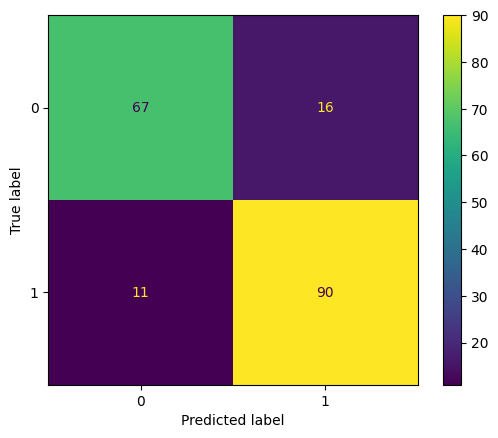

In [307]:
cm_v2 = confusion_matrix(y_test, y_pred_v2)
disp_model_v2 =  ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=clf_v2.classes_)

disp_model_v2.plot();

The metrics from the two model versions show almost no impact on wether using ```oldpeak``` or not.

### Model v3: Dropping ```max_hr_predicted```

In [315]:
X_train_v3 = X_train.drop(["max_hr_predicted"], axis=1)
X_test_v3 = X_test.drop(["max_hr_predicted"], axis=1)

In [314]:
clf_v3 = LogisticRegression(max_iter=1500, random_state=16)
clf_v3.fit(X_train_v3, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",16
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [316]:
y_pred_v3 = clf_v3.predict(X_test_v3)

In [325]:
print("###############################")
print(f"Model v1 Accuracy Score: {accuracy_score(y_test, y_pred_v1):.2f}")
print(f"Model v2 Accuracy Score: {accuracy_score(y_test, y_pred_v2):.2f}")
print(f"Model v3 Accuracy Score: {accuracy_score(y_test, y_pred_v3):.2f}")
print("###############################")
print(f"Model v1 Precision Score: {precision_score(y_test, y_pred_v1):.2f}")
print(f"Model v2 Precision Score: {precision_score(y_test, y_pred_v2):.2f}")
print(f"Model v3 Precision Score: {precision_score(y_test, y_pred_v3):.2f}")
print("###############################")
print(f"Model v1 Recall Score: {recall_score(y_test, y_pred_v1):.2f}")
print(f"Model v2 Recall Score: {recall_score(y_test, y_pred_v2):.2f}")
print(f"Model v3 Recall Score: {recall_score(y_test, y_pred_v3):.2f}")
print("###############################")

###############################
Model v1 Accuracy Score: 0.85
Model v2 Accuracy Score: 0.85
Model v3 Accuracy Score: 0.85
###############################
Model v1 Precision Score: 0.85
Model v2 Precision Score: 0.85
Model v3 Precision Score: 0.85
###############################
Model v1 Recall Score: 0.88
Model v2 Recall Score: 0.89
Model v3 Recall Score: 0.88
###############################


## Random Forest

In [221]:
X_rndmfrst = df_final.drop(["heartdisease", "oldpeak", "max_hr_predicted"], axis=1)
y_rf = df_final["heartdisease"]

In [222]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rndmfrst, y_rf, test_size=0.2)

In [237]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=16)

model.fit(X_train_rf, y_train_rf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [238]:
y_pred_rf = model.predict(X_test_rf)

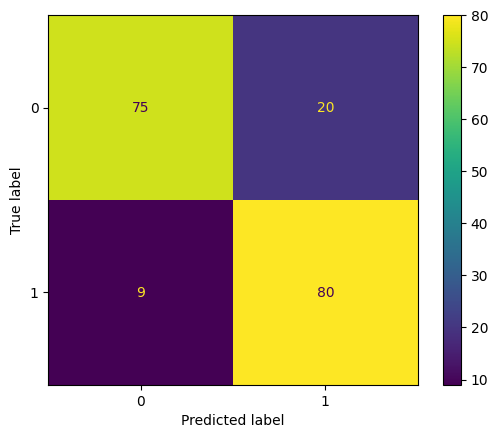

In [328]:
cm_rndmfrst = confusion_matrix(y_test_rf, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rndmfrst, display_labels = model.classes_)
disp.plot();

In [330]:
print(f"Random Forest Recall Score: {recall_score(y_test_rf, y_pred_rf):.2f}")
print(f"Random Forest Acuraccy Score: {accuracy_score(y_test_rf, y_pred_rf):.2f}")
print(f"Random Forest Precision Score: {precision_score(y_test_rf, y_pred_rf):.2f}")

Random Forest Recall Score: 0.90
Random Forest Acuraccy Score: 0.84
Random Forest Precision Score: 0.80


## Conclusion

While the Random Forest algorithm achieves a higher recall score, Logistic Regression presents more balanced performance across all evaluated metrics. If the primary goal is to identify as many positive cases as possible, Random Forest would be the preferred choice. However, considering the overall balance between precision and recall, as well as the relatively small difference in performance, Logistic Regression emerges as a more cost-effective and stable solution. Therefore, for this project, Logistic Regression was selected as the final model.